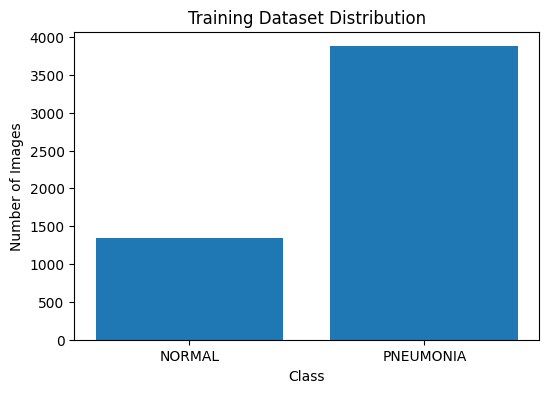

In [ ]:
import matplotlib.pyplot as plt

# Class distribution counts
classes = ["NORMAL", "PNEUMONIA"]
counts = [1342, 3876]

# Create bar chart
plt.figure(figsize=(6,4))
plt.bar(classes, counts)
plt.title("Training Dataset Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()


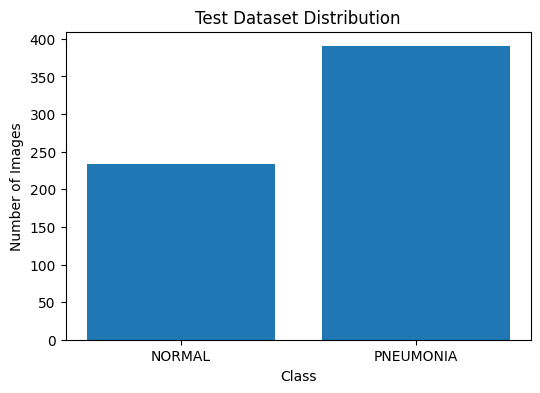

In [ ]:
import matplotlib.pyplot as plt

# Class distribution counts
classes = ["NORMAL", "PNEUMONIA"]
counts = [234,390]

# bar chart
plt.figure(figsize=(6,4))
plt.bar(classes, counts)
plt.title("Test Dataset Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()


The random images from train directory


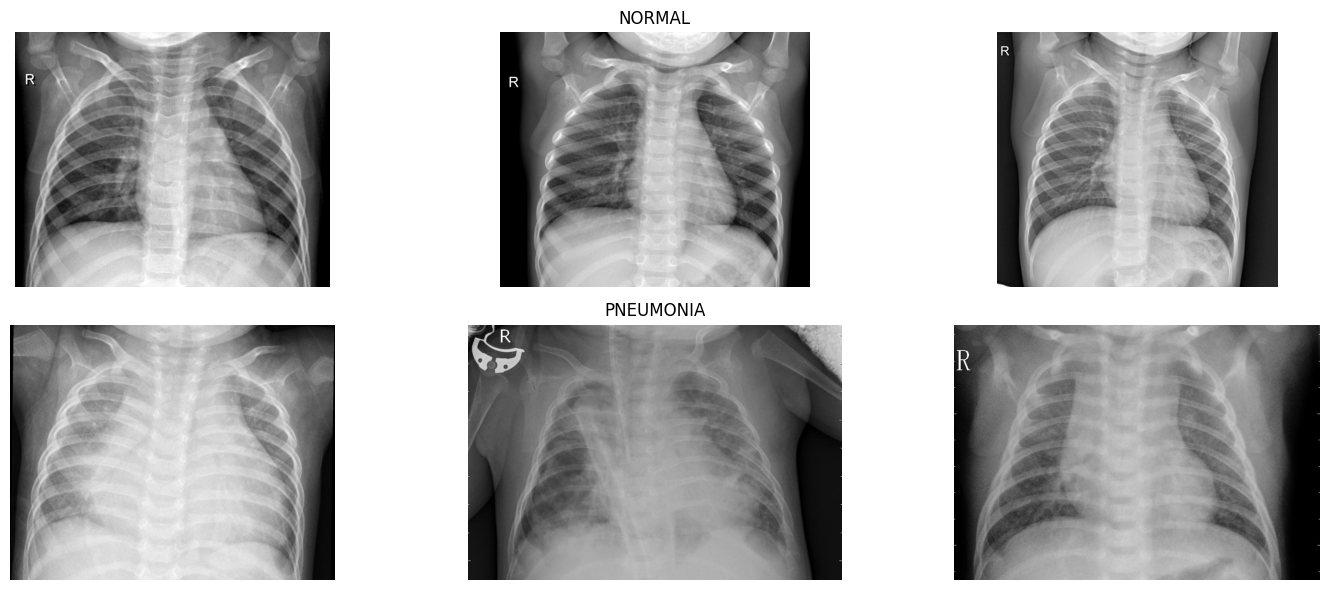

In [ ]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Parameters
num_images = 3

# Create a figure
plt.figure(figsize=(15, 6))

# Looping through each class folder
class_folders = os.listdir(train_dir)
for idx, cls in enumerate(class_folders):
    class_path = os.path.join(train_dir, cls)
    images = os.listdir(class_path)

    # Randomly pick images
    sample_images = random.sample(images, num_images)

    for i, img in enumerate(sample_images):
        img_path = os.path.join(class_path, img)
        plt.subplot(len(class_folders), num_images, idx * num_images + i + 1)
        plt.imshow(mpimg.imread(img_path), cmap='gray')
        plt.axis('off')
        if i == num_images // 2:
            plt.title(cls)
print('The random images from train directory')
plt.tight_layout()
plt.show()


The random images from test directory


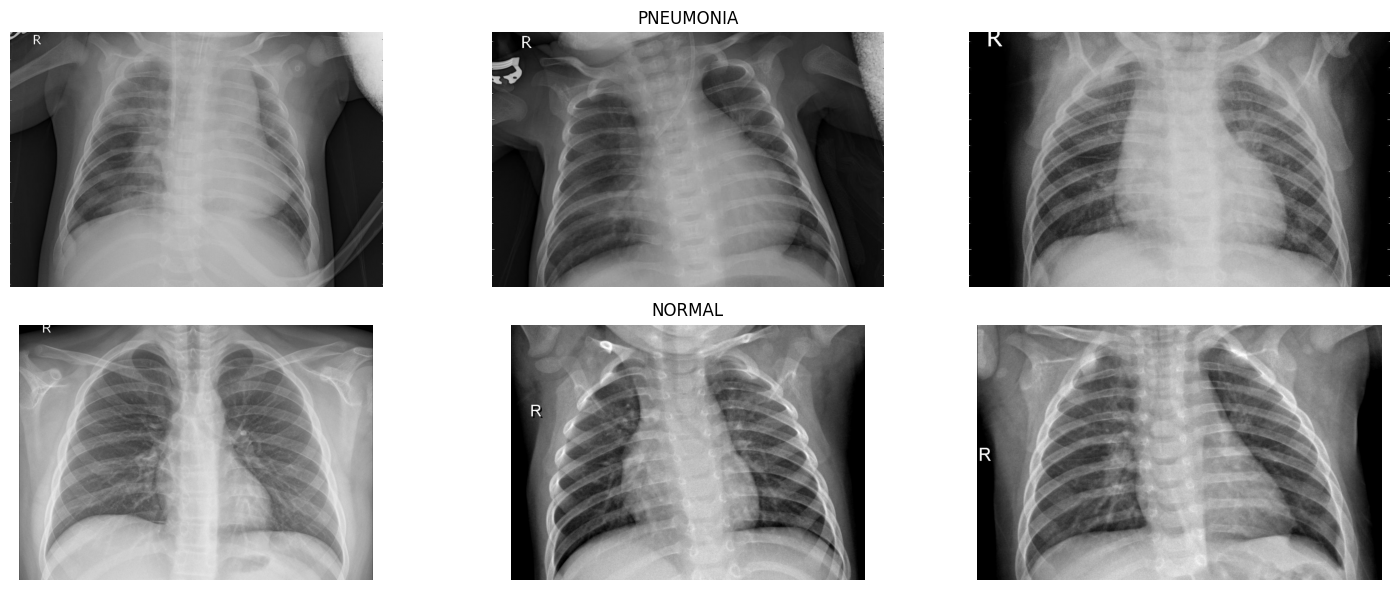

In [ ]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Parameters
num_images = 3  # how many random images per class to show

# Create a figure
plt.figure(figsize=(15, 6))

# Loop through each class folder
class_folders = os.listdir(test_dir)
for idx, cls in enumerate(class_folders):
    class_path = os.path.join(test_dir, cls)
    images = os.listdir(class_path)

    # Randomly pick images
    sample_images = random.sample(images, num_images)

    for i, img in enumerate(sample_images):
        img_path = os.path.join(class_path, img)
        plt.subplot(len(class_folders), num_images, idx * num_images + i + 1)
        plt.imshow(mpimg.imread(img_path), cmap='gray')
        plt.axis('off')
        if i == num_images // 2:
            plt.title(cls)
print('The random images from test directory')
plt.tight_layout()
plt.show()


In [ ]:
if os.path.exists(train_dir):
    for x in os.listdir(train_dir):
        print(x, len(os.listdir(os.path.join(train_dir, x))))
else:
    print(f"Error: Directory not found at {train_dir}")

BACTERIAL PNE 2538
VIRAL PNE 1345


In [ ]:
if os.path.exists(test_dir):
  for sub_dir in os.listdir(test_dir):
    print(sub_dir, len(os.listdir(os.path.join(test_dir, sub_dir))))
else:
  print(f"Error: Directory not found at {test_dir}")

BACTERIAL PNE 242
VIRAL PNE 148


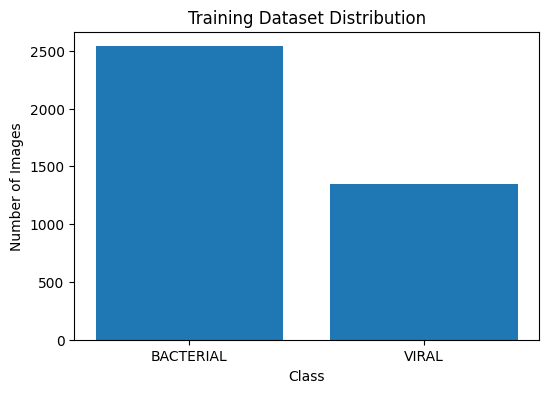

In [ ]:
import matplotlib.pyplot as plt

# Class distribution counts
classes = ["BACTERIAL", "VIRAL"]
counts = [2538, 1345]

# Create bar chart
plt.figure(figsize=(6,4))
plt.bar(classes, counts)
plt.title("Training Dataset Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()


The random images from train directory


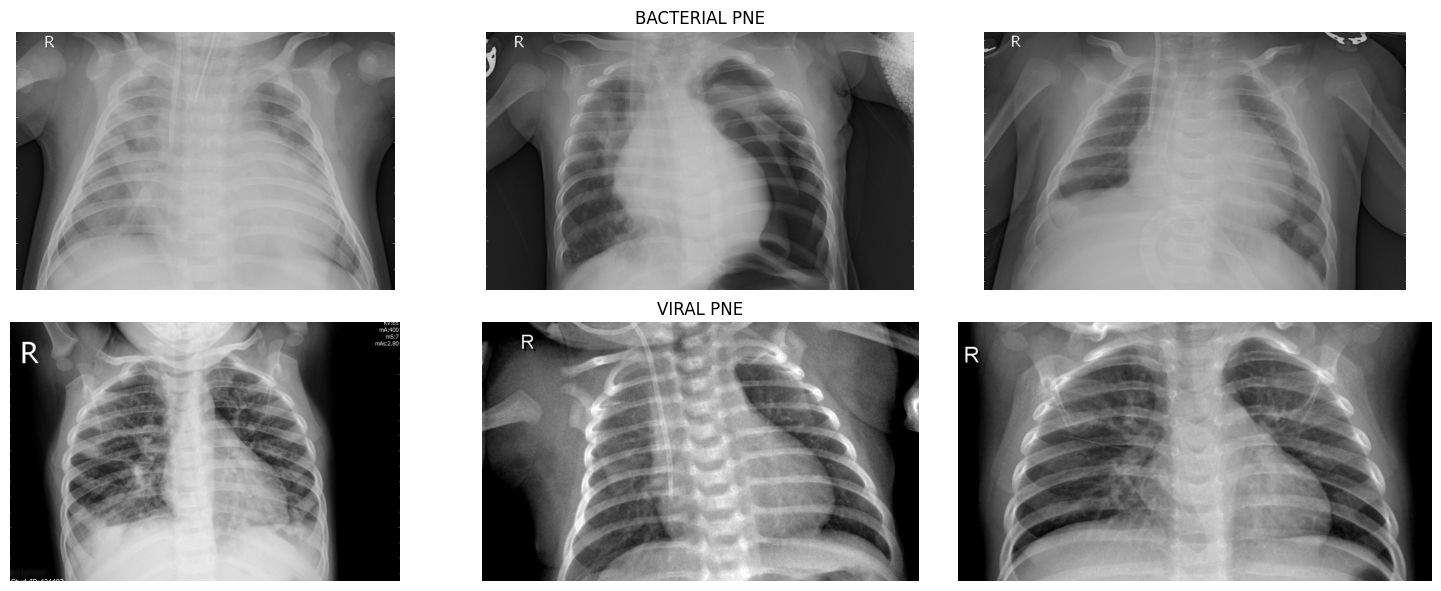

In [ ]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Parameters
num_images = 3

# Create a figure
plt.figure(figsize=(15, 6))

# Loop through each class folder
class_folders = os.listdir(train_dir)
for idx, cls in enumerate(class_folders):
    class_path = os.path.join(train_dir, cls)
    images = os.listdir(class_path)

    # Randomly pick images
    sample_images = random.sample(images, num_images)

    for i, img in enumerate(sample_images):
        img_path = os.path.join(class_path, img)
        plt.subplot(len(class_folders), num_images, idx * num_images + i + 1)
        plt.imshow(mpimg.imread(img_path), cmap='gray')
        plt.axis('off')
        if i == num_images // 2:
            plt.title(cls)
print('The random images from train directory')
plt.tight_layout()
plt.show()


The random images from train directory


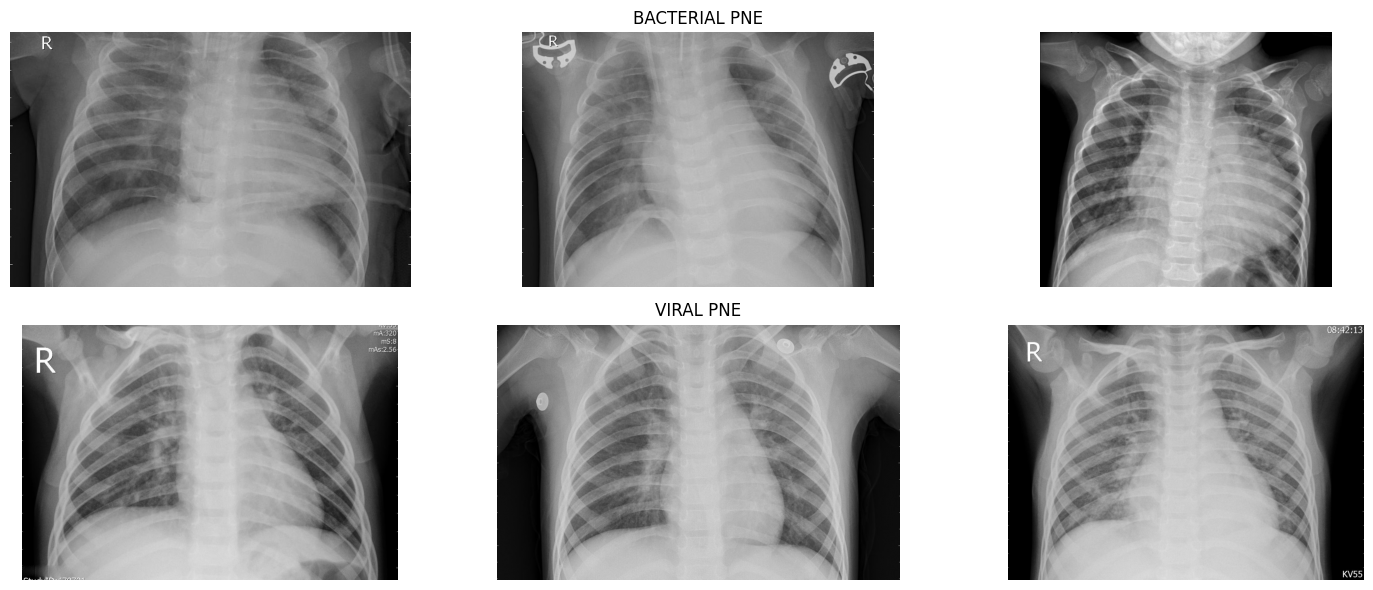

In [ ]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Parameters
num_images = 3

# Create a figure
plt.figure(figsize=(15, 6))

# Loop through each class folder
class_folders = os.listdir(test_dir)
for idx, cls in enumerate(class_folders):
    class_path = os.path.join(test_dir, cls)
    images = os.listdir(class_path)

    # Randomly pick images
    sample_images = random.sample(images, num_images)

    for i, img in enumerate(sample_images):
        img_path = os.path.join(class_path, img)
        plt.subplot(len(class_folders), num_images, idx * num_images + i + 1)
        plt.imshow(mpimg.imread(img_path), cmap='gray')
        plt.axis('off')
        if i == num_images // 2:
            plt.title(cls)
print('The random images from test directory')
plt.tight_layout()
plt.show()


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
import os


# Path to save models
save_dir = "/content/drive/MyDrive/saved_models"
os.makedirs(save_dir, exist_ok=True)


def get_base_model(input_shape=(224,224,3)):
    base_model = DenseNet201(weights='imagenet', include_top=False, input_shape=input_shape)
    return base_model

# ===============================
# BUILD TRANSFER LEARNING MODEL
# ===============================
def build_model(base_model, num_classes=2):
    inputs = Input(shape=(224,224,3))
    x = base_model(inputs)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs, outputs)
    return model

# MAIN TRAINING
if __name__ == "__main__":
    data_augmentation = tf.keras.Sequential([
        tf.keras.layers.Rescaling(1./255),
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.05),
        tf.keras.layers.RandomZoom(0.05),
        tf.keras.layers.RandomContrast(0.1),
    ])

    # Load datasets
    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_dir,
        labels='inferred',
        label_mode='categorical',
        image_size=(224,224),
        batch_size=32,
        shuffle=True
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        val_dir,
        labels='inferred',
        label_mode='categorical',
        image_size=(224,224),
        batch_size=32,
        shuffle=False
    )

    # Apply augmentation only on training data
    train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))
    AUTOTUNE = tf.data.AUTOTUNE
    train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
    val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

    # COMPUTE CLASS WEIGHTS

    labels = np.concatenate([y.numpy() for x, y in train_ds.unbatch()])

    # If categorical one-hot, convert to class indices
    if labels.ndim > 1:
        labels = np.argmax(labels, axis=1)

    print("Label shape:", labels.shape)
    print("Unique labels:", np.unique(labels, return_counts=True))

    class_weights_array = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(labels),
        y=labels
    )
    class_weights = dict(enumerate(class_weights_array))
    print("Class Weights:", class_weights)

    # ===============================
    # BUILD MODEL
    # ===============================
    base_model = get_base_model()
    for layer in base_model.layers:
        layer.trainable = False
    model = build_model(base_model)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Callbacks
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    # Save full model
    checkpoint_full = ModelCheckpoint(
        os.path.join(save_dir, "best_modelP5.h5"),
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    )

    # Save weights only
    checkpoint_weights = ModelCheckpoint(
        os.path.join(save_dir, "best_modelP5.weights.h5"),
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    )

    # ===============================
    # INITIAL TRAINING
    # ===============================
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=50,
        callbacks=[early_stop, checkpoint_full, checkpoint_weights],
        class_weight=class_weights   # <--- balance added
    )

    # ===============================
    # FINE-TUNING
    # ===============================
    print("\nStarting fine-tuning...")
    for layer in base_model.layers[-30:]:
        layer.trainable = True

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history_fine_tune = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=50,
        initial_epoch=history.epoch[-1] + 1,
        callbacks=[early_stop, checkpoint_full, checkpoint_weights],
        class_weight=class_weights   # <--- balance added
    )

    print("Fine-tuning complete. Models saved in Google Drive.")


Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Label shape: (10432,)
Unique labels: (array([0., 1.], dtype=float32), array([5216, 5216]))
Class Weights: {0: np.float64(1.0), 1: np.float64(1.0)}
74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.5319 - loss: 1.0600
Epoch 1: val_loss improved from inf to 1.11607, saving model to /content/drive/MyDrive/saved_models/best_modelP5.h5



Epoch 1: val_loss improved from inf to 1.11607, saving model to /content/drive/MyDrive/saved_models/best_modelP5.weights.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 122s 437ms/step - accuracy: 0.5323 - loss: 1.0587 - val_accuracy: 0.6250 - val_loss: 1.1161
Epoch 2/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.7000 - loss: 0.6373
Epoch 2: val_loss did not improve from 1.11607

Epoch 2: val_loss did not improve from 1.11607
163/163 ━━━━━━━━━━━━━━━━━━━━ 59s 120ms/step - accuracy: 0.7001 - loss: 0.6371 - val_accuracy: 0.6250 - val_loss: 1.1427
Epoch 3/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.7612 - loss: 0.5292
Epoch 3: val_loss improved from 1.11607 to 1.08214, saving model to /content/drive/MyDrive/saved_models/best_modelP5.h5



Epoch 3: val_loss improved from 1.11607 to 1.08214, saving model to /content/drive/MyDrive/saved_models/best_modelP5.weights.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 27s 161ms/step - accuracy: 0.7612 - loss: 0.5290 - val_accuracy: 0.6250 - val_loss: 1.0821
Epoch 4/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.8075 - loss: 0.4334
Epoch 4: val_loss did not improve from 1.08214

Epoch 4: val_loss did not improve from 1.08214
163/163 ━━━━━━━━━━━━━━━━━━━━ 19s 115ms/step - accuracy: 0.8075 - loss: 0.4333 - val_accuracy: 0.5625 - val_loss: 1.1055
Epoch 5/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.8218 - loss: 0.3844
Epoch 5: val_loss improved from 1.08214 to 1.03514, saving model to /content/drive/MyDrive/saved_models/best_modelP5.h5



Epoch 5: val_loss improved from 1.08214 to 1.03514, saving model to /content/drive/MyDrive/saved_models/best_modelP5.weights.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 26s 158ms/step - accuracy: 0.8218 - loss: 0.3844 - val_accuracy: 0.5625 - val_loss: 1.0351
Epoch 6/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.8484 - loss: 0.3473
Epoch 6: val_loss improved from 1.03514 to 0.96274, saving model to /content/drive/MyDrive/saved_models/best_modelP5.h5



Epoch 6: val_loss improved from 1.03514 to 0.96274, saving model to /content/drive/MyDrive/saved_models/best_modelP5.weights.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 26s 157ms/step - accuracy: 0.8485 - loss: 0.3472 - val_accuracy: 0.6250 - val_loss: 0.9627
Epoch 7/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.8505 - loss: 0.3347
Epoch 7: val_loss did not improve from 0.96274

Epoch 7: val_loss did not improve from 0.96274
163/163 ━━━━━━━━━━━━━━━━━━━━ 19s 117ms/step - accuracy: 0.8505 - loss: 0.3346 - val_accuracy: 0.5625 - val_loss: 1.0023
Epoch 8/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.8682 - loss: 0.3012
Epoch 8: val_loss improved from 0.96274 to 0.96061, saving model to /content/drive/MyDrive/saved_models/best_modelP5.h5


...


Epoch 39: val_loss improved from 0.27574 to 0.27082, saving model to /content/drive/MyDrive/saved_models/best_modelP5.weights.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 29s 176ms/step - accuracy: 0.9910 - loss: 0.0347 - val_accuracy: 0.8125 - val_loss: 0.2708
Epoch 40/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.9919 - loss: 0.0323
Epoch 40: val_loss improved from 0.27082 to 0.24624, saving model to /content/drive/MyDrive/saved_models/best_modelP5.h5



Epoch 40: val_loss improved from 0.27082 to 0.24624, saving model to /content/drive/MyDrive/saved_models/best_modelP5.weights.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 31s 190ms/step - accuracy: 0.9919 - loss: 0.0323 - val_accuracy: 0.8750 - val_loss: 0.2462
Epoch 41/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.9935 - loss: 0.0295
Epoch 41: val_loss improved from 0.24624 to 0.22634, saving model to /content/drive/MyDrive/saved_models/best_modelP5.h5



Epoch 41: val_loss improved from 0.24624 to 0.22634, saving model to /content/drive/MyDrive/saved_models/best_modelP5.weights.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 33s 204ms/step - accuracy: 0.9935 - loss: 0.0295 - val_accuracy: 0.8750 - val_loss: 0.2263
Epoch 42/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.9960 - loss: 0.0260
Epoch 42: val_loss improved from 0.22634 to 0.21511, saving model to /content/drive/MyDrive/saved_models/best_modelP5.h5



Epoch 42: val_loss improved from 0.22634 to 0.21511, saving model to /content/drive/MyDrive/saved_models/best_modelP5.weights.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 38s 189ms/step - accuracy: 0.9960 - loss: 0.0260 - val_accuracy: 0.8750 - val_loss: 0.2151
Epoch 43/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.9957 - loss: 0.0234
Epoch 43: val_loss did not improve from 0.21511

Epoch 43: val_loss did not improve from 0.21511
163/163 ━━━━━━━━━━━━━━━━━━━━ 30s 123ms/step - accuracy: 0.9957 - loss: 0.0234 - val_accuracy: 0.8750 - val_loss: 0.2234
Epoch 44/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.9971 - loss: 0.0207
Epoch 44: val_loss did not improve from 0.21511

Epoch 44: val_loss did not improve from 0.21511
163/163 ━━━━━━━━━━━━━━━━━━━━ 20s 123ms/step - accuracy: 0.9971 - loss: 0.0207 - val_accuracy: 0.8750 - val_loss: 0.2505
Epoch 45/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.9979 - loss: 0.0176
Epoch 45: val_loss improved from 0.21511 to 0.176


Epoch 45: val_loss improved from 0.21511 to 0.17672, saving model to /content/drive/MyDrive/saved_models/best_modelP5.weights.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 28s 171ms/step - accuracy: 0.9979 - loss: 0.0176 - val_accuracy: 0.8750 - val_loss: 0.1767
Epoch 46/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.9980 - loss: 0.0176
Epoch 46: val_loss did not improve from 0.17672

Epoch 46: val_loss did not improve from 0.17672
163/163 ━━━━━━━━━━━━━━━━━━━━ 33s 120ms/step - accuracy: 0.9980 - loss: 0.0176 - val_accuracy: 0.8750 - val_loss: 0.2028
Epoch 47/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.9983 - loss: 0.0164
Epoch 47: val_loss did not improve from 0.17672

Epoch 47: val_loss did not improve from 0.17672
163/163 ━━━━━━━━━━━━━━━━━━━━ 21s 124ms/step - accuracy: 0.9983 - loss: 0.0164 - val_accuracy: 0.8750 - val_loss: 0.1895
Epoch 48/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.9992 - loss: 0.0131
Epoch 48: val_loss did not improve from 0.17672



Found 624 files belonging to 2 classes.
20/20 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.97      0.66      0.79       234
   PNEUMONIA       0.83      0.99      0.90       390

    accuracy                           0.87       624
   macro avg       0.90      0.82      0.84       624
weighted avg       0.88      0.87      0.86       624


Confusion Matrix:
[[155  79]
 [  5 385]]


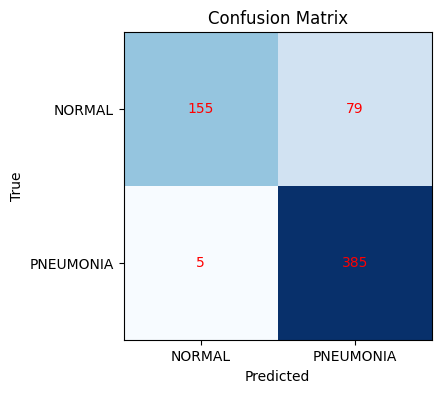

ROC-AUC: 0.9457812842428227


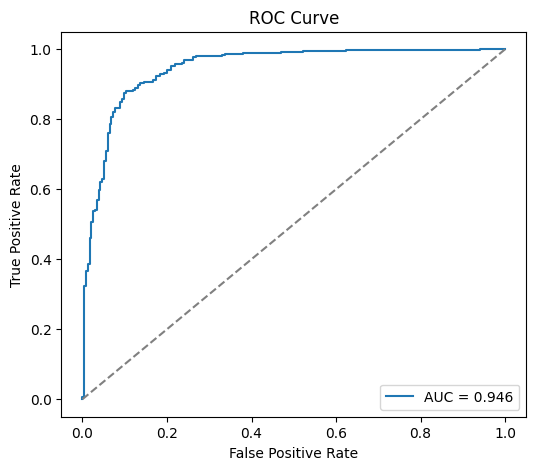

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt



test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='categorical',
    image_size=(224,224),
    batch_size=32,
    shuffle=False
)

# ===============================
# Predictions
# ===============================
y_true = np.concatenate([y.numpy() for x, y in test_ds])
y_true = np.argmax(y_true, axis=1)

y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# ===============================
# Metrics
# ===============================
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=test_ds.class_names))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_true, y_pred)
print(cm)

# Plot Confusion Matrix
plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xticks([0,1], test_ds.class_names)
plt.yticks([0,1], test_ds.class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="red")
plt.show()

# ===============================
# ROC & AUC
# ===============================
if y_pred_probs.shape[1] == 2:  # binary classification
    auc = roc_auc_score(y_true, y_pred_probs[:,1])
    fpr, tpr, _ = roc_curve(y_true, y_pred_probs[:,1])

    print("ROC-AUC:", auc)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    plt.plot([0,1], [0,1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

MODEL 2

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import (
    VGG16, VGG19,
    ResNet50, ResNet101, ResNet152,
    DenseNet121, DenseNet169, DenseNet201,
    InceptionV3, InceptionResNetV2,
    Xception,
    MobileNet, MobileNetV2, MobileNetV3Small, MobileNetV3Large,
    EfficientNetB0, EfficientNetB1, EfficientNetB2, EfficientNetB3,
    EfficientNetB4, EfficientNetB5, EfficientNetB6, EfficientNetB7
)
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# ======================================
# 1. DATASET LOADING + AUGMENTATION
# ======================================
base_dir = '/content/drive/MyDrive/subclass/'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_ds = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary"
)
val_ds = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary"
)
test_ds = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary"
)

# ======================================
# 2. DEFINE MODEL ARCHITECTURES
# ======================================
models_dict = {
    "VGG16": VGG16,
    "ResNet50": ResNet50,
    "DenseNet121": DenseNet121,
    "InceptionV3": InceptionV3,
    "Xception": Xception,
    "MobileNetV2": MobileNetV2,
    "EfficientNetB0": EfficientNetB0,
}


# ======================================
# 3. TRAIN LOOP
# ======================================
input_shape = (224, 224, 3)
epochs = 10

for name, arch in models_dict.items():
    print(f"\n==============================")
    print(f"Training {name} for {epochs} epochs")
    print(f"==============================")

    try:
        base_model = arch(weights="imagenet", include_top=False, input_shape=input_shape)
    except Exception as e:
        print(f"⚠️ Skipping {name} due to error: {e}")
        continue

    base_model.trainable = False  # freeze backbone

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        verbose=1
    )

    loss, acc = model.evaluate(test_ds, verbose=0)
    print(f"{name} Test Accuracy: {acc:.4f}")


Found 3761 images belonging to 2 classes.
Found 158 images belonging to 2 classes.
Found 248 images belonging to 2 classes.

Training VGG16 for 10 epochs
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 562s 5s/step - accuracy: 0.5734 - loss: 0.6894 - val_accuracy: 0.7025 - val_loss: 0.5943
Epoch 2/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 76s 643ms/step - accuracy: 0.6644 - loss: 0.6369 - val_accuracy: 0.7025 - val_loss: 0.5791
Epoch 3/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 77s 652ms/step - accuracy: 0.6645 - loss: 0.6248 - val_accuracy: 0.7025 - val_loss: 0.5670
Epoch 4/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 77s 648ms/step - accuracy: 0.6568 - loss: 0.6221 - val_accuracy: 0.7025 - val_loss: 0.5480
Epoch 5/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 77s 648ms/step - accuracy: 0.6811 - loss: 0.6081 - val_accuracy: 0.7152 - val_loss: 0.5366
Epoch 6/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 75s 635ms/step - accuracy: 0.6894 - loss: 0.5920 - val_accuracy: 0.7405 - val_loss: 0.5258
Epoch 7/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 76s 640ms/step - accuracy: 0.6905 - loss: 0.5863 - val_accuracy: 0.7658 - val_loss: 0.5173
Epoch 8/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 78s 657ms/step - accuracy: 0.7025 - loss: 0.5

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import (
    VGG16, VGG19,
    ResNet50, ResNet101, ResNet152,
    DenseNet121, DenseNet169, DenseNet201,
    InceptionV3, InceptionResNetV2,
    Xception,
    MobileNet, MobileNetV2, MobileNetV3Small, MobileNetV3Large,
    EfficientNetB0, EfficientNetB1, EfficientNetB2, EfficientNetB3,
    EfficientNetB4, EfficientNetB5, EfficientNetB6, EfficientNetB7
)
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# ======================================
# 1. DATASET LOADING + AUGMENTATION
# ======================================
base_dir = '/content/drive/MyDrive/subclass/'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_ds = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary"
)
val_ds = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary"
)
test_ds = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary"
)

# ======================================
# 2. DEFINE MODEL ARCHITECTURES
# ======================================
models_dict = {
    "VGG19": VGG19,
    "ResNet101": ResNet101,
    "ResNet152": ResNet152,
    "DenseNet169": DenseNet169,
    "DenseNet201": DenseNet201,
    "InceptionResNetV2": InceptionResNetV2,
    "MobileNet": MobileNet,
    "MobileNetV3Small": MobileNetV3Small,
    "MobileNetV3Large": MobileNetV3Large,
    "EfficientNetB1": EfficientNetB1,
    "EfficientNetB2": EfficientNetB2,
    "EfficientNetB3": EfficientNetB3,
    "EfficientNetB4": EfficientNetB4,
    "EfficientNetB5": EfficientNetB5,
    "EfficientNetB6": EfficientNetB6,
    "EfficientNetB7": EfficientNetB7
}



# ======================================
# 3. TRAIN LOOP
# ======================================
input_shape = (224, 224, 3)
epochs = 10

for name, arch in models_dict.items():
    print(f"\n==============================")
    print(f"Training {name} for {epochs} epochs")
    print(f"==============================")

    try:
        base_model = arch(weights="imagenet", include_top=False, input_shape=input_shape)
    except Exception as e:
        print(f"⚠️ Skipping {name} due to error: {e}")
        continue

    base_model.trainable = False  # freeze backbone

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid")  # binary classification (bacterial vs viral)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        verbose=1
    )

    loss, acc = model.evaluate(test_ds, verbose=0)
    print(f"{name} Test Accuracy: {acc:.4f}")


Found 3761 images belonging to 2 classes.
Found 158 images belonging to 2 classes.
Found 248 images belonging to 2 classes.

Training VGG19 for 10 epochs
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 84s 687ms/step - accuracy: 0.6321 - loss: 0.6584 - val_accuracy: 0.7025 - val_loss: 0.6008
Epoch 2/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 78s 664ms/step - accuracy: 0.6484 - loss: 0.6491 - val_accuracy: 0.7025 - val_loss: 0.5906
Epoch 3/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 78s 661ms/step - accuracy: 0.6487 - loss: 0.6401 - val_accuracy: 0.7025 - val_loss: 0.5754
Epoch 4/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 82s 693ms/step - accuracy: 0.6646 - loss: 0.6218 - val_accuracy: 0.7025 - val_loss: 0.5668
Epoch 5/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 79s 668ms/step - accuracy: 0.6735 - loss: 0.6143 - val_accuracy: 0.7025 - val_loss: 0.5581
Epoch 6/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 80s 675ms/step - accuracy: 0.6720 - loss: 0.6211 - val_accuracy: 0.7215 - val_loss: 0.5535
Epoch 7/1

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import (
    VGG16, VGG19,
    ResNet50, ResNet101, ResNet152,
    DenseNet121, DenseNet169, DenseNet201,
    InceptionV3, InceptionResNetV2,
    Xception,
    MobileNet, MobileNetV2, MobileNetV3Small, MobileNetV3Large,
    EfficientNetB0, EfficientNetB1, EfficientNetB2, EfficientNetB3,
    EfficientNetB4, EfficientNetB5, EfficientNetB6, EfficientNetB7
)
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# ======================================
# 1. DATASET LOADING + AUGMENTATION
# ======================================
base_dir = '/content/drive/MyDrive/subclass/'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_ds = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary"
)
val_ds = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary"
)
test_ds = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary"
)

# ======================================
# 2. DEFINE MODEL ARCHITECTURES
# ======================================
models_dict = {
    "DenseNet201": DenseNet201,
    "InceptionResNetV2": InceptionResNetV2,
    "MobileNet": MobileNet,
    "MobileNetV3Small": MobileNetV3Small,
    "MobileNetV3Large": MobileNetV3Large,
    "EfficientNetB1": EfficientNetB1,
    "EfficientNetB2": EfficientNetB2
}



# ======================================
# 3. TRAIN LOOP
# ======================================
input_shape = (224, 224, 3)
epochs = 10

for name, arch in models_dict.items():
    print(f"\n==============================")
    print(f"Training {name} for {epochs} epochs")
    print(f"==============================")

    try:
        base_model = arch(weights="imagenet", include_top=False, input_shape=input_shape)
    except Exception as e:
        print(f"⚠️ Skipping {name} due to error: {e}")
        continue

    base_model.trainable = False  # freeze backbone

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid")  # binary classification (bacterial vs viral)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        verbose=1
    )

    loss, acc = model.evaluate(test_ds, verbose=0)
    print(f"{name} Test Accuracy: {acc:.4f}")


Found 3761 images belonging to 2 classes.
Found 158 images belonging to 2 classes.
Found 248 images belonging to 2 classes.

Training DenseNet201 for 10 epochs
74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 794s 6s/step - accuracy: 0.6729 - loss: 0.6214 - val_accuracy: 0.7975 - val_loss: 0.4934
Epoch 2/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 74s 626ms/step - accuracy: 0.7290 - loss: 0.5409 - val_accuracy: 0.8165 - val_loss: 0.4706
Epoch 3/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 74s 626ms/step - accuracy: 0.7641 - loss: 0.5182 - val_accuracy: 0.8291 - val_loss: 0.4587
Epoch 4/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 82s 625ms/step - accuracy: 0.7747 - loss: 0.5126 - val_accuracy: 0.8291 - val_loss: 0.4493
Epoch 5/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 74s 628ms/step - accuracy: 0.7767 - loss: 0.4999 - val_accuracy: 0.8481 - val_loss: 0.4399
Epoch 6/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 75s 632ms/step - accuracy: 0.7621 - loss: 0.5134 - val_accuracy: 0.8165 - val_loss: 0.4499
Epoch 7/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 75s 638ms/step - accuracy: 0.7738 - loss: 0.4902 - val_accuracy: 0.8228 - val_loss: 0.4392
Epoch 8/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 74s 625ms/step - accuracy: 0.7738 - loss: 0.4

In [ ]:
train_dir = '/content/drive/MyDrive/subclass/train'
test_dir = '/content/drive/MyDrive/subclass/test'
val_dir = '/content/drive/MyDrive/subclass/val'

In [ ]:
# ===============================
# IMPORTS
# ===============================
import tensorflow as tf
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
import os

# ===============================
# MOUNT GOOGLE DRIVE


# Path to save models
save_dir = "/content/drive/MyDrive/saved_models"
os.makedirs(save_dir, exist_ok=True)

# ===============================
# BASE MODEL FUNCTION
# ===============================
def get_base_model(input_shape=(224,224,3)):
    base_model = MobileNet(weights='imagenet', include_top=False, input_shape=input_shape)
    return base_model

# ===============================
# BUILD TRANSFER LEARNING MODEL
# ===============================
def build_model(base_model, num_classes=2):
    inputs = Input(shape=(224,224,3))
    x = base_model(inputs)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs, outputs)
    return model

# ===============================
# MAIN TRAINING
# ===============================
if __name__ == "__main__":
    # Data augmentation (removed RandomBrightness)
    data_augmentation = tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.05),
        tf.keras.layers.RandomZoom(0.05),
        tf.keras.layers.RandomContrast(0.1),
    ])

    # Load datasets
    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_dir,
        labels='inferred',
        label_mode='categorical',
        image_size=(224,224),
        batch_size=32,
        shuffle=True
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        val_dir,
        labels='inferred',
        label_mode='categorical',
        image_size=(224,224),
        batch_size=32,
        shuffle=False
    )

    # Apply augmentation only on training data
    train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))
    AUTOTUNE = tf.data.AUTOTUNE
    train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
    val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

    # ===============================
    # COMPUTE CLASS WEIGHTS
    # ===============================
    labels = np.concatenate([y.numpy() for x, y in train_ds.unbatch()])

    # If categorical one-hot, convert to class indices
    if labels.ndim > 1:
        labels = np.argmax(labels, axis=1)

    print("Label shape:", labels.shape)
    print("Unique labels:", np.unique(labels, return_counts=True))

    class_weights_array = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(labels),
        y=labels
    )
    class_weights = dict(enumerate(class_weights_array))
    print("Class Weights:", class_weights)

    # ===============================
    # BUILD MODEL
    # ===============================
    base_model = get_base_model()
    for layer in base_model.layers:
        layer.trainable = False
    model = build_model(base_model)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Callbacks
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    # Save full model
    checkpoint_full = ModelCheckpoint(
        os.path.join(save_dir, "mod2new.h5"),
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    )

    # Save weights only
    checkpoint_weights = ModelCheckpoint(
        os.path.join(save_dir, "mod2new.weights.h5"),
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    )

    # ===============================
    # INITIAL TRAINING
    # ===============================
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=50,
        callbacks=[early_stop, checkpoint_full, checkpoint_weights],
        class_weight=class_weights   # <--- balance added
    )

    # ===============================
    # FINE-TUNING
    # ===============================
    print("\nStarting fine-tuning...")
    for layer in base_model.layers[-30:]:
        layer.trainable = True

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history_fine_tune = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=50,
        initial_epoch=history.epoch[-1] + 1,
        callbacks=[early_stop, checkpoint_full, checkpoint_weights],
        class_weight=class_weights   # <--- balance added
    )

    print("Fine-tuning complete. Models saved in Google Drive.")


Found 3761 files belonging to 2 classes.
Found 158 files belonging to 2 classes.
Label shape: (7522,)
Unique labels: (array([0., 1.], dtype=float32), array([3761, 3761]))
Class Weights: {0: np.float64(1.0), 1: np.float64(1.0)}
Epoch 1/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.6151 - loss: 0.8671
Epoch 1: val_loss improved from inf to 0.58927, saving model to /content/drive/MyDrive/saved_models/mod2new.h5



Epoch 1: val_loss improved from inf to 0.58927, saving model to /content/drive/MyDrive/saved_models/mod2new.weights.h5
118/118 ━━━━━━━━━━━━━━━━━━━━ 18s 109ms/step - accuracy: 0.6150 - loss: 0.8667 - val_accuracy: 0.7152 - val_loss: 0.5893
Epoch 2/50
117/118 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6062 - loss: 0.7550
Epoch 2: val_loss improved from 0.58927 to 0.56458, saving model to /content/drive/MyDrive/saved_models/mod2new.h5



Epoch 2: val_loss improved from 0.58927 to 0.56458, saving model to /content/drive/MyDrive/saved_models/mod2new.weights.h5
118/118 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.6066 - loss: 0.7546 - val_accuracy: 0.7342 - val_loss: 0.5646
Epoch 3/50
117/118 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6397 - loss: 0.7287
Epoch 3: val_loss improved from 0.56458 to 0.55960, saving model to /content/drive/MyDrive/saved_models/mod2new.h5



Epoch 3: val_loss improved from 0.56458 to 0.55960, saving model to /content/drive/MyDrive/saved_models/mod2new.weights.h5
118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.6400 - loss: 0.7283 - val_accuracy: 0.7468 - val_loss: 0.5596
Epoch 4/50
117/118 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6519 - loss: 0.7141
Epoch 4: val_loss improved from 0.55960 to 0.55210, saving model to /content/drive/MyDrive/saved_models/mod2new.h5



Epoch 4: val_loss improved from 0.55960 to 0.55210, saving model to /content/drive/MyDrive/saved_models/mod2new.weights.h5
118/118 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.6519 - loss: 0.7140 - val_accuracy: 0.7595 - val_loss: 0.5521
Epoch 5/50
117/118 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6456 - loss: 0.7166
Epoch 5: val_loss improved from 0.55210 to 0.54444, saving model to /content/drive/MyDrive/saved_models/mod2new.h5


...


Epoch 40: val_loss improved from 0.49257 to 0.49091, saving model to /content/drive/MyDrive/saved_models/mod2new.weights.h5
118/118 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.7443 - loss: 0.5398 - val_accuracy: 0.7722 - val_loss: 0.4909
Epoch 41/50
117/118 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7407 - loss: 0.5264
Epoch 41: val_loss did not improve from 0.49091

Epoch 41: val_loss did not improve from 0.49091
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.7408 - loss: 0.5264 - val_accuracy: 0.7658 - val_loss: 0.4941
Epoch 42/50
117/118 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7389 - loss: 0.5313
Epoch 42: val_loss improved from 0.49091 to 0.49082, saving model to /content/drive/MyDrive/saved_models/mod2new.h5



Epoch 42: val_loss improved from 0.49091 to 0.49082, saving model to /content/drive/MyDrive/saved_models/mod2new.weights.h5
118/118 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.7390 - loss: 0.5313 - val_accuracy: 0.7722 - val_loss: 0.4908
Epoch 43/50
117/118 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7397 - loss: 0.5423
Epoch 43: val_loss did not improve from 0.49082

Epoch 43: val_loss did not improve from 0.49082
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.7398 - loss: 0.5422 - val_accuracy: 0.7658 - val_loss: 0.4921
Epoch 44/50
117/118 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7381 - loss: 0.5427
Epoch 44: val_loss improved from 0.49082 to 0.48793, saving model to /content/drive/MyDrive/saved_models/mod2new.h5



Epoch 44: val_loss improved from 0.49082 to 0.48793, saving model to /content/drive/MyDrive/saved_models/mod2new.weights.h5
118/118 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.7382 - loss: 0.5425 - val_accuracy: 0.7848 - val_loss: 0.4879
Epoch 45/50
117/118 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7431 - loss: 0.5319
Epoch 45: val_loss did not improve from 0.48793

Epoch 45: val_loss did not improve from 0.48793
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.7432 - loss: 0.5318 - val_accuracy: 0.7658 - val_loss: 0.4941
Epoch 46/50
117/118 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7473 - loss: 0.5302
Epoch 46: val_loss did not improve from 0.48793

Epoch 46: val_loss did not improve from 0.48793
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.7473 - loss: 0.5302 - val_accuracy: 0.7722 - val_loss: 0.4893
Epoch 47/50
117/118 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7464 - loss: 0.5375
Epoch 47: val_loss improved from 0.48793 to 0.48710, saving mod


Epoch 47: val_loss improved from 0.48793 to 0.48710, saving model to /content/drive/MyDrive/saved_models/mod2new.weights.h5
118/118 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.7465 - loss: 0.5374 - val_accuracy: 0.7722 - val_loss: 0.4871
Epoch 48/50
117/118 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7439 - loss: 0.5338
Epoch 48: val_loss did not improve from 0.48710

Epoch 48: val_loss did not improve from 0.48710
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.7440 - loss: 0.5338 - val_accuracy: 0.7785 - val_loss: 0.4901
Epoch 49/50
117/118 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7393 - loss: 0.5345
Epoch 49: val_loss improved from 0.48710 to 0.48498, saving model to /content/drive/MyDrive/saved_models/mod2new.h5



Epoch 49: val_loss improved from 0.48710 to 0.48498, saving model to /content/drive/MyDrive/saved_models/mod2new.weights.h5
118/118 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.7395 - loss: 0.5344 - val_accuracy: 0.7785 - val_loss: 0.4850
Epoch 50/50
117/118 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7491 - loss: 0.5234
Epoch 50: val_loss did not improve from 0.48498

Epoch 50: val_loss did not improve from 0.48498
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.7492 - loss: 0.5234 - val_accuracy: 0.7658 - val_loss: 0.4907

Starting fine-tuning...
Fine-tuning complete. Models saved in Google Drive.


Found 248 files belonging to 2 classes.
8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 921ms/step

Classification Report:
              precision    recall  f1-score   support

   BACTERIAL       0.91      0.89      0.90       139
       VIRAL       0.86      0.88      0.87       109

    accuracy                           0.89       248
   macro avg       0.88      0.89      0.89       248
weighted avg       0.89      0.89      0.89       248


Confusion Matrix:
[[124  15]
 [ 13  96]]


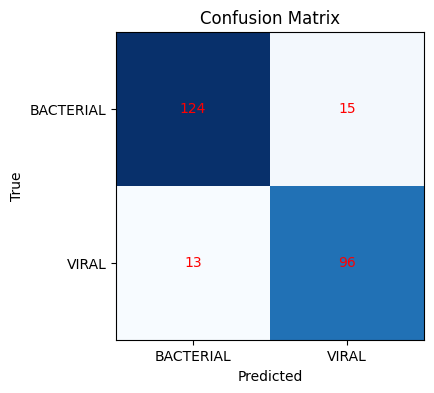

ROC-AUC: 0.9458121576133589


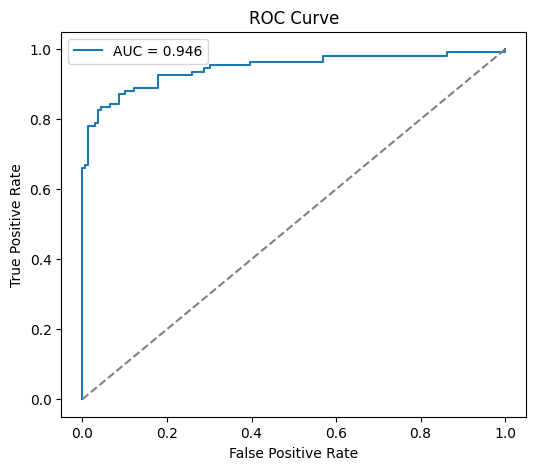

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt



test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='categorical',
    image_size=(224,224),
    batch_size=32,
    shuffle=False
)

# ===============================
# Predictions
# ===============================
y_true = np.concatenate([y.numpy() for x, y in test_ds])
y_true = np.argmax(y_true, axis=1)

y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# ===============================
# Metrics
# ===============================
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=test_ds.class_names))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_true, y_pred)
print(cm)

# Plot Confusion Matrix
plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xticks([0,1], test_ds.class_names)
plt.yticks([0,1], test_ds.class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="red")
plt.show()

# ===============================
# ROC & AUC
# ===============================
if y_pred_probs.shape[1] == 2:  # binary classification
    auc = roc_auc_score(y_true, y_pred_probs[:,1])
    fpr, tpr, _ = roc_curve(y_true, y_pred_probs[:,1])

    print("ROC-AUC:", auc)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    plt.plot([0,1], [0,1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()